# Сегментация изображений

## Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>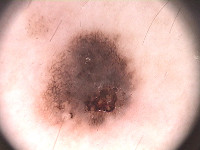</td><td>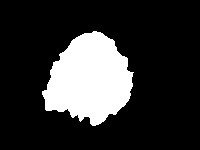</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [ ]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=930a0b59-7c83-472a-963a-e1e4d6fa4802
To: /content/PH2Dataset.rar
100% 162M/162M [00:00<00:00, 194MB/s]


In [ ]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [ ]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на  256×256  пикселей. Для изменения размера изображений можно использовать skimage.transform.resize(). Эта функция также автоматически нормализует изображения в диапазоне  [0,1] .

In [ ]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [ ]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

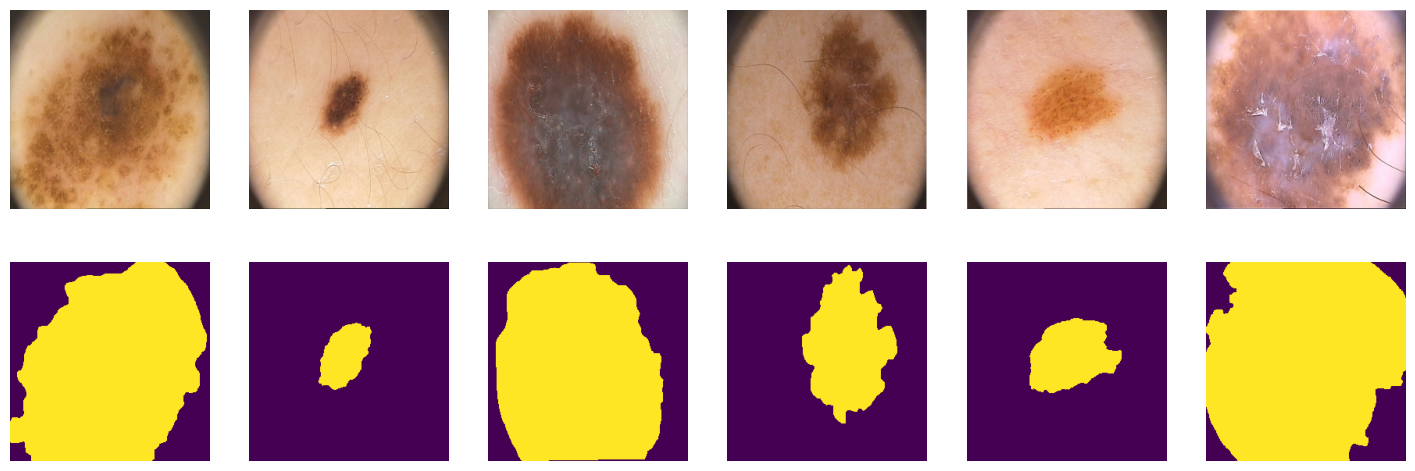

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50 для обучения, валидации и теста соответственно

In [ ]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [ ]:
print(len(tr), len(val), len(ts))

100 50 50


### PyTorch DataLoader

In [ ]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [ ]:
!pip install torchmetrics

In [ ]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

## Первый baseline

Остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

### Loss функция - BCE

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

#### Вывод численно стабильной формулы

Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**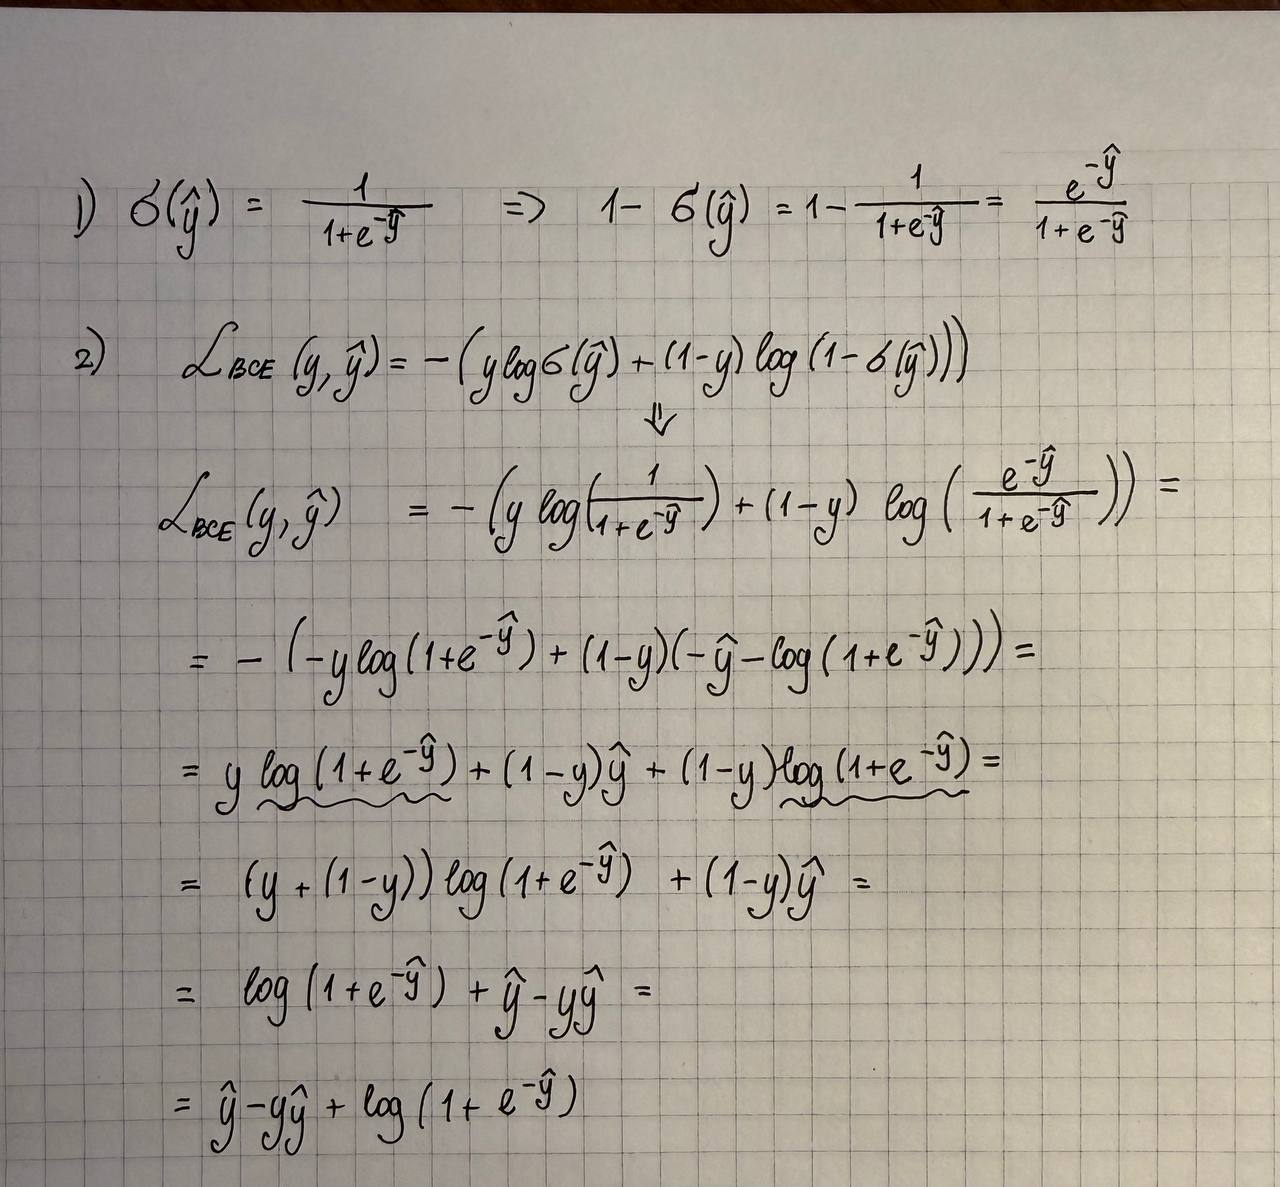

#### Реализуем в коде оба варианта лосса

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

In [ ]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [ ]:
def bce_loss(y_pred, y_real):
  y_prob = torch.sigmoid(y_pred)
  loss = -torch.sum(y_real * torch.log(y_prob + 1e-8) + (1 - y_real) * torch.log(1 - y_prob + 1e-8))
  return loss

def bce_true(y_pred, y_real):
  loss = torch.sum(y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred)))
  return loss

Проверим корректность работы на простом примере

In [ ]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')

BCE loss from scratch bce_loss             = 5.768119812011719
BCE loss честно посчитанный                = 5.768119812011719
BCE loss from torch bce_torch              = 5.768119812011719
BCE loss from torch with logits bce_torch  = 5.768120288848877


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [ ]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 14.150577545166016
BCE loss честно посчитанный               = 14.150577545166016
BCE loss from torch bce_torch             = 14.150578498840332
BCE loss from torch with logits bce_torch = 14.150578498840332


In [ ]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [ ]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 4.10MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 5.41MB/s]
Download completed


In [ ]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

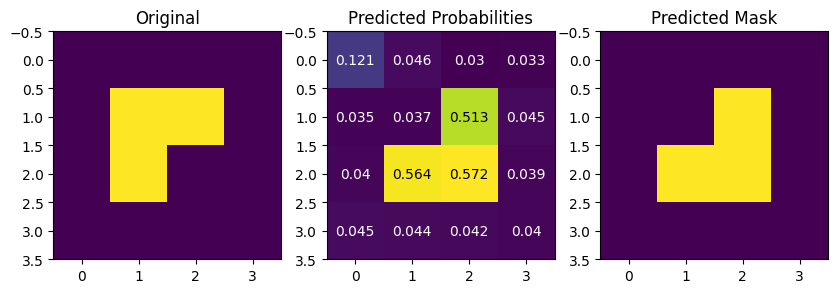

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [ ]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

### Модель SegNet

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

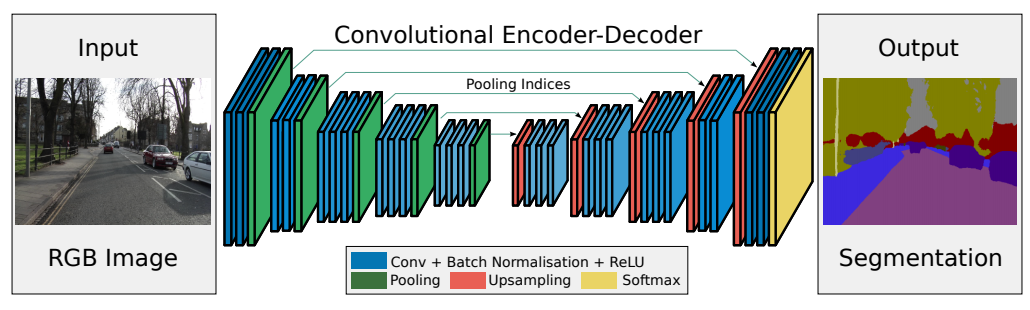

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

In [ ]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

In [ ]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:

два блока со структурой: Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
три блока со структурой: Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.

In [ ]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:

в первом блоке декодера количество каналов не меняется
во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
на выходе из последнего блока декодера 1 канал
Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth,
                 kernel_size=3, padding=1, is_last=False):

        super(DecoderBlock, self).__init__()

        self.unpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)

        self.layers = nn.ModuleList()

        for i in range(depth - 1):
            self.layers.append(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=in_channels,
                    kernel_size=kernel_size,
                    padding=padding
                )
            )
            self.layers.append(nn.BatchNorm2d(in_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding
            )
        )

        if not is_last:
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, indices):
        # unpooling без output_size
        x = self.unpooling(x, indices)

        for layer in self.layers:
            x = layer(x)

        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [ ]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64):
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=2)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=2)

        # Bottleneck
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=2)

        # Decoder
        self.decoder4 = DecoderBlock(num_features * 8, num_features * 8, depth=2, is_last=False)
        self.decoder3 = DecoderBlock(num_features * 8, num_features * 4, depth=2, is_last=False)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=2, is_last=False)
        self.decoder1 = DecoderBlock(num_features * 2, num_features, depth=2, is_last=False)
        self.decoder0 = DecoderBlock(num_features, out_channels, depth=2, is_last=True)

    def forward(self, x):

        # Encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)

        # Decoder
        x = self.decoder4(x, indices4)
        x = self.decoder3(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder1(x, indices1)
        x = self.decoder0(x, indices0)

        return x

### Тренировка модели

In [ ]:
from tqdm.notebook import tqdm
from torchmetrics import JaccardIndex

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [ ]:
def train_single_epoch(model, optimizer, criterion,
                       train_dataloader, device):

    model.train()

    avg_loss = 0.0

    for X_batch, y_batch in tqdm(train_dataloader):

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).float()

        optimizer.zero_grad()

        y_pred = model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        optimizer.step()

        avg_loss += loss.item()

    avg_loss = avg_loss / len(train_dataloader)

    return model, avg_loss


def validate_single_epoch(model,
                          criterion,
                          valid_dataloader,
                          device,
                          plot=False):

    iou_score = JaccardIndex(
        task="binary",
        threshold=0.5
    ).to(device)

    model.eval()

    avg_loss = 0.0
    avg_iou = 0.0

    with torch.no_grad():

        for X_batch, Y_batch in tqdm(valid_dataloader):

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device).float()

            Y_pred = model(X_batch)

            loss = criterion(Y_pred, Y_batch)

            pred_mask = torch.sigmoid(Y_pred)
            pred_mask = (pred_mask > 0.5).int()

            iou = iou_score(pred_mask, Y_batch.int())

            avg_loss += loss.item()
            avg_iou += iou.item()

    avg_loss = avg_loss / len(valid_dataloader)
    avg_iou = avg_iou / len(valid_dataloader)

    if plot:

        clear_output(wait=True)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # image
        orig_img = X_batch[0].permute(1, 2, 0).cpu().numpy()

        # true mask
        true_mask = Y_batch[0].squeeze().cpu().numpy()

        # predicted mask
        pred_vis = pred_mask[0].squeeze().cpu().numpy()

        axes[0].imshow(orig_img)
        axes[0].set_title("Image")

        axes[1].imshow(true_mask, cmap='gray')
        axes[1].set_title("True Mask")

        axes[2].imshow(pred_vis, cmap='gray')
        axes[2].set_title(f"Prediction | IoU={avg_iou:.4f}")

        plt.show()

    return model, avg_loss, avg_iou

In [ ]:
def train(model,
          optimizer,
          criterion,
          epochs,
          train_dataloader,
          valid_dataloader,
          device,
          ckpt_path,
          plot_loss=False):

    total_train_loss = []
    total_val_loss = []
    total_val_iou = []

    best_val_loss = float('inf')

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        # train
        model, train_loss = train_single_epoch(
            model,
            optimizer,
            criterion,
            train_dataloader,
            device
        )

        # validation
        model, val_loss, val_iou = validate_single_epoch(
            model,
            criterion,
            valid_dataloader,
            device,
            plot=True
        )

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_loss:.4f}")
        print(f"Val IoU:    {val_iou:.4f}")

        total_train_loss.append(train_loss)
        total_val_loss.append(val_loss)
        total_val_iou.append(val_iou)

        # plots
        if plot_loss:

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

            ax1.plot(total_train_loss, label='Train Loss')
            ax1.plot(total_val_loss, label='Val Loss')
            ax1.set_title("Loss")
            ax1.legend()

            ax2.plot(total_val_iou, label='Val IoU')
            ax2.set_title("IoU")
            ax2.legend()

            plt.show()

        # save best model
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                model.state_dict(),
                f'{ckpt_path}/best_model.pt'
            )

            print("Best model saved")

    statistics = {
        'train_loss': total_train_loss,
        'val_loss': total_val_loss,
        'val_iou': total_val_iou
    }

    return model, statistics

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = SegNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = bce_torch_with_logits

In [ ]:
epochs = 20
ckpt_path = '/content/checkpoints'

In [ ]:
import os

ckpt_path = "/content/checkpoints"

os.makedirs(ckpt_path, exist_ok=True)

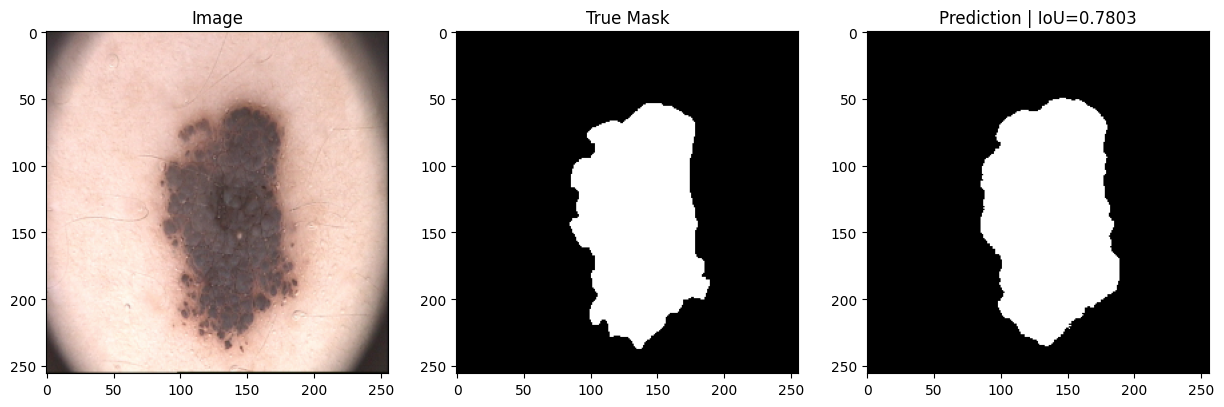

Train Loss: 250607.2109
Val Loss:   337024.8594
Val IoU:    0.7803


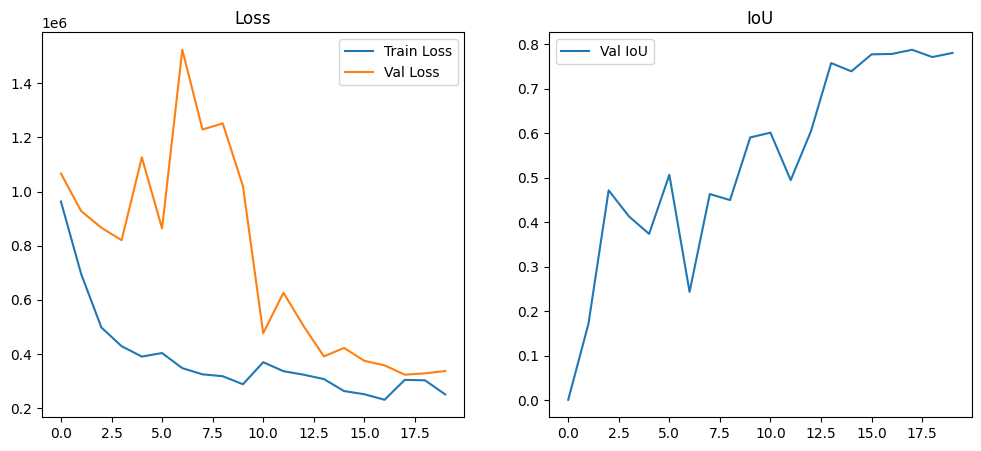

In [ ]:
model, statistics = train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path, plot_loss = True)

## Другие лоссы

### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

In [ ]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    '''
    Это именно метрика, не лосс.
    '''
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    labels = labels.float()
    tp = (preds * labels).sum()
    fp = (preds * (1 - labels)).sum()
    fn = ((1 - preds) * labels).sum()
    eps = 1e-8
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)

    return score

Проверим на корректность функцию dice_score:

In [ ]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
score = dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].float())
print(score)

tensor(1., device='cuda:0')


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


Давайте теперь пропишем лосс и воспользуемся библиотекой segmentation-models-pytorch, чтобы убедиться в корректности нашей функции.

In [ ]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
  probs = torch.sigmoid(logits)
  labels = labels.float()

  probs = probs.view(probs.size(0), -1)
  labels = labels.view(labels.size(0), -1)

  intersection = (probs * labels).sum(dim=1)
  union = probs.sum(dim=1) + labels.sum(dim=1)

  eps = 1e-8
  dice = (2 * intersection + eps) / (union + eps)

  loss = 1 - dice.mean()

  return loss

Проверка на корректность:

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.1 MB/s eta 0:00:00


In [ ]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [ ]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [ ]:
def focal_loss(logits, targets, gamma=2.0, alpha=0.5, eps=1e-8):

    probs = torch.sigmoid(logits)
    targets = targets.float()

    pt = probs * targets + (1 - probs) * (1 - targets)

    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        reduction='none'
    )

    loss = (1 - pt) ** gamma * bce

    return loss.mean()

Проверка корректности функции:

In [ ]:
from torchvision.ops import sigmoid_focal_loss
loss_tv = sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'].float(), alpha=-1, gamma=2, reduction='sum')
loss_custom = focal_loss( dummpy_sample['logits'], dummpy_sample['labels'], gamma=2)

In [ ]:
assert torch.allclose(loss_tv, loss_custom, atol=1e-4)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

### Tverky Loss

In [ ]:
def tversky_loss(logits, labels, alpha=0.5, beta=0.5, eps=1e-8):

    probs = torch.sigmoid(logits)
    labels = labels.float()

    tp = (probs * labels).sum()
    fp = (probs * (1 - labels)).sum()
    fn = ((1 - probs) * labels).sum()

    tversky = (tp + eps) / (tp + alpha * fp + beta * fn + eps)

    return 1 - tversky

### Boundary Loss

In [ ]:
from scipy.ndimage import distance_transform_edt

def boundary_loss(pred, mask):

    pred = torch.sigmoid(pred)

    mask = mask.cpu().numpy()

    dt = distance_transform_edt(1 - mask)

    dt = torch.tensor(dt, device=pred.device).float()

    loss = (pred * dt).mean()

    return loss

### Correlation/SSIM Loss

In [ ]:
import torch.nn.functional as F
def ssim_loss(pred, target):

    pred = torch.sigmoid(pred)
    target = target.float()

    mu_x = pred.mean()
    mu_y = target.mean()

    sigma_x = pred.var()
    sigma_y = target.var()

    sigma_xy = ((pred - mu_x) * (target - mu_y)).mean()

    c1 = 1e-4
    c2 = 1e-4

    ssim = ((2*mu_x*mu_y + c1)*(2*sigma_xy + c2))/((mu_x**2 + mu_y**2 + c1)*(sigma_x + sigma_y + c2))

    return 1 - ssim

### Topology-preserving loss

In [ ]:
def topology_loss(pred, target):

    pred = torch.sigmoid(pred)

    return torch.abs(pred - target.float()).mean()

### Emotion loss

In [ ]:
def emotion_loss(logits, labels):

    bce = torch.nn.functional.binary_cross_entropy_with_logits(logits, labels.float())

    smooth_l1 = torch.nn.functional.l1_loss(torch.sigmoid(logits), labels.float())

    return bce + 0.5 * smooth_l1

## Обучение SegNet на новых лоссах

BCE

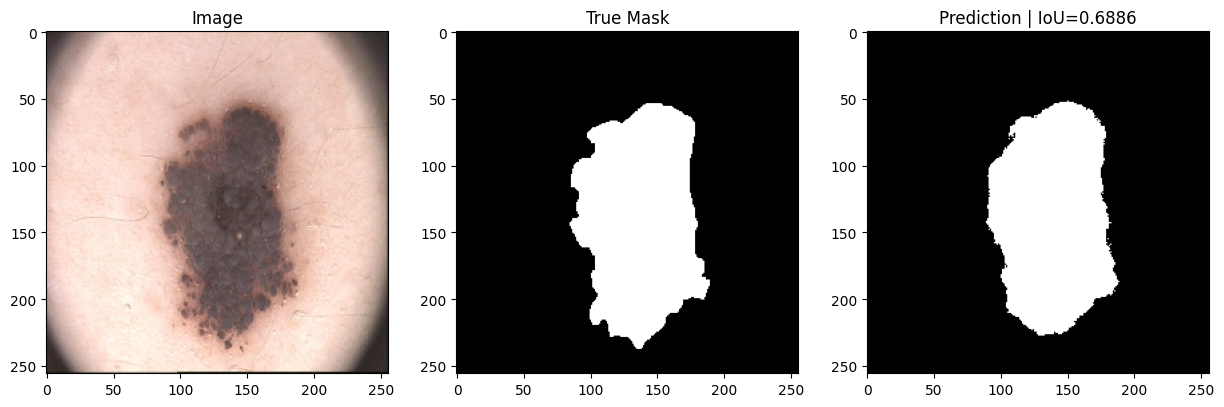

Train Loss: 0.1854
Val Loss:   0.2800
Val IoU:    0.6886


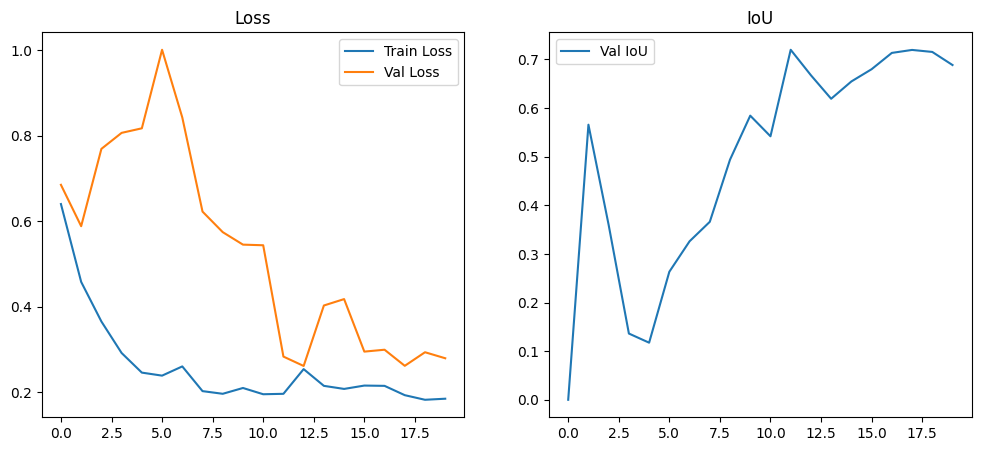

In [ ]:
ckpt_path_bce = "/content/checkpoints/bce"

os.makedirs(ckpt_path_bce, exist_ok=True)

model_bce = SegNet().to(device)
optimizer_bce = optim.Adam(model_bce.parameters(), lr=1e-3)
criterion_bce = nn.BCEWithLogitsLoss()

model_bce, stats_bce = train(
    model_bce,
    optimizer_bce,
    criterion_bce,
    epochs,
    train_dataloader,
    valid_dataloader,
    device,
    ckpt_path_bce,
    plot_loss=True
)

Dice

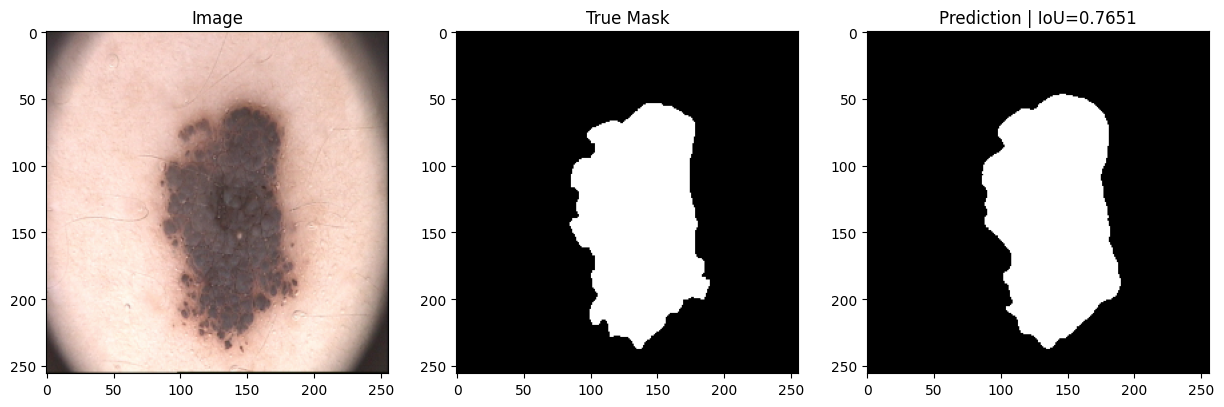

Train Loss: 0.1189
Val Loss:   0.1456
Val IoU:    0.7651


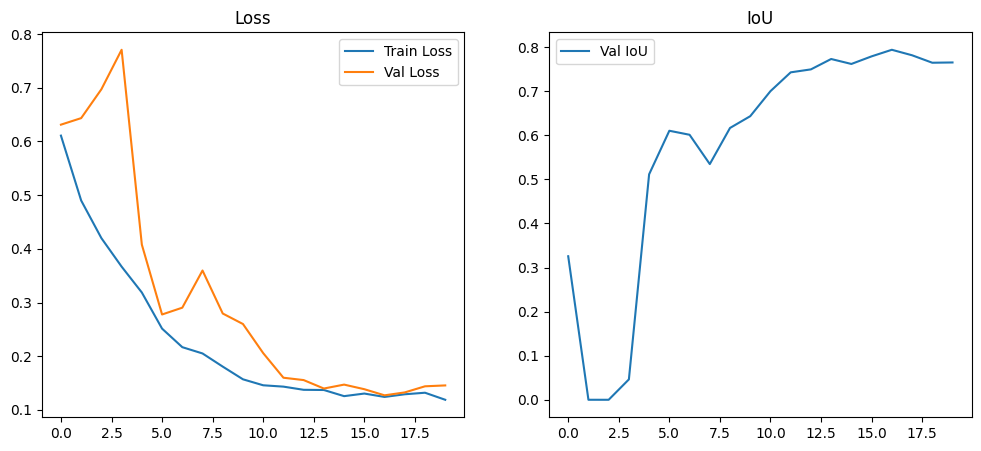

In [ ]:
ckpt_path_dice = "/content/checkpoints/dice"

os.makedirs(ckpt_path_dice, exist_ok=True)

model_dice = SegNet().to(device)
optimizer_dice = optim.Adam(model_dice.parameters(), lr=1e-3)
criterion_dice = dice_loss

model_dice, stats_dice = train(
    model_dice,
    optimizer_dice,
    criterion_dice,
    epochs,
    train_dataloader,
    valid_dataloader,
    device,
    ckpt_path_dice,
    plot_loss=True
)

Focal Loss

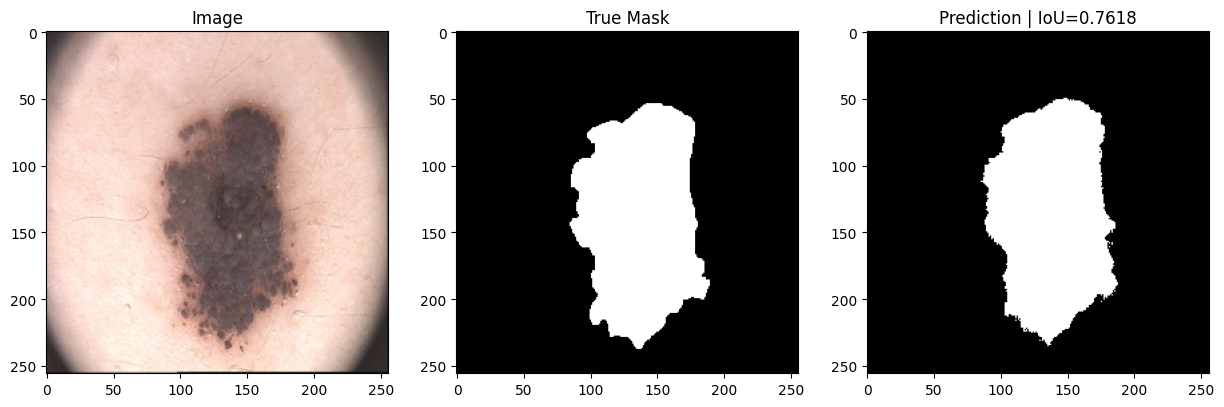

Train Loss: 0.0575
Val Loss:   0.0604
Val IoU:    0.7618


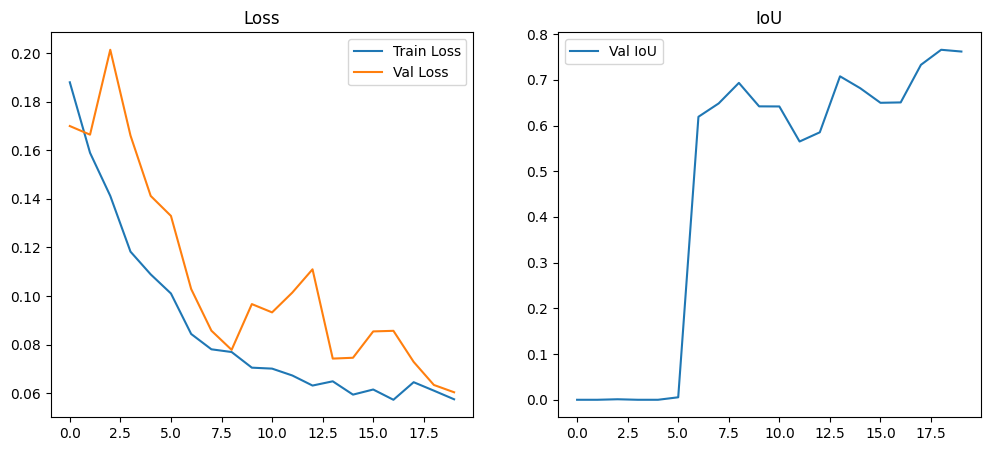

Best model saved


In [ ]:
import torch.nn.functional as F

ckpt_path_focal = "/content/checkpoints/focal"

os.makedirs(ckpt_path_focal, exist_ok=True)

model_focal = SegNet().to(device)
optimizer_focal = optim.Adam(model_focal.parameters(), lr=1e-3)
criterion_focal = focal_loss

model_focal, stats_focal = train(
    model_focal,
    optimizer_focal,
    criterion_focal,
    epochs,
    train_dataloader,
    valid_dataloader,
    device,
    ckpt_path_focal,
    plot_loss=True
)

Модель сходится быстрее при focal loss (0,0604). Он быстрее всего уменьшает loss, так как он учитывает сложность распределения классов (фокусируется на сложных пикселях).

Лучшую метрику модель дает при dice loss (0,7651), так как он оптимизирует перекрытие предсказанной и истинной маски.

## Модель U-Net

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

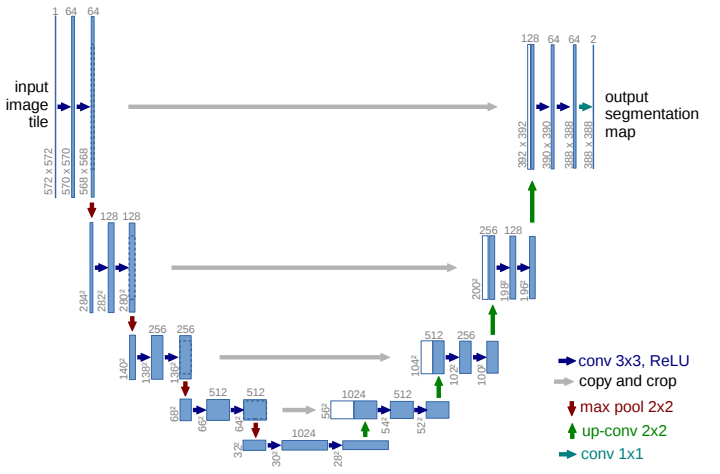

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # Output
        self.out = nn.Conv2d(64, n_class, 1)

    def forward(self, x):

        # Encoder
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))

        # Bottleneck
        x5 = self.bottleneck(self.pool(x4))

        # Decoder
        d4 = self.up4(x5)
        d4 = torch.cat([d4, x4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, x3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, x2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, x1], dim=1)
        d1 = self.dec1(d1)

        output = self.out(d1)

        return output

In [ ]:
unet_model = UNet().to(device)

## Обучение U-Net

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



### BCE

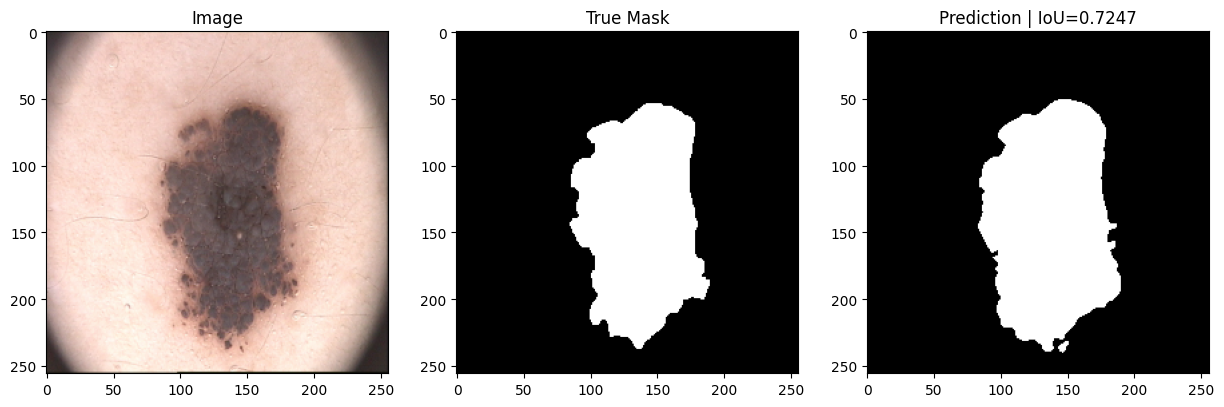

Train Loss: 0.1801
Val Loss:   0.2682
Val IoU:    0.7247


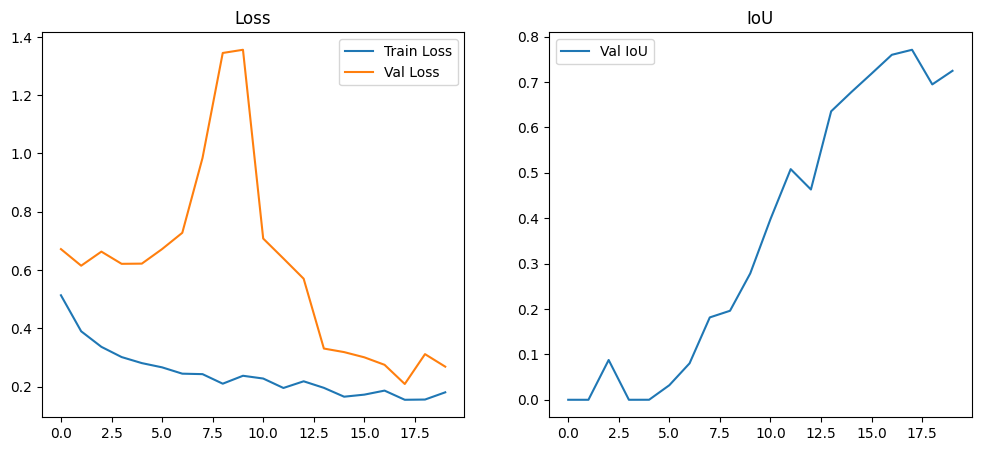

In [ ]:
ckpt_path_unet_bce = "/content/checkpoints/unet_bce"

os.makedirs(ckpt_path_unet_bce, exist_ok=True)

model_unet_bce = UNet(n_class=1).to(device)
optimizer_unet_bce = torch.optim.Adam(model_unet_bce.parameters(), lr=1e-3)
criterion_bce = torch.nn.BCEWithLogitsLoss()

model_unet_bce, stats_unet_bce = train(
    model_unet_bce,
    optimizer_unet_bce,
    criterion_bce,
    epochs,
    train_dataloader,
    valid_dataloader,
    device,
    ckpt_path_unet_bce,
    plot_loss=True
)

### Dice loss

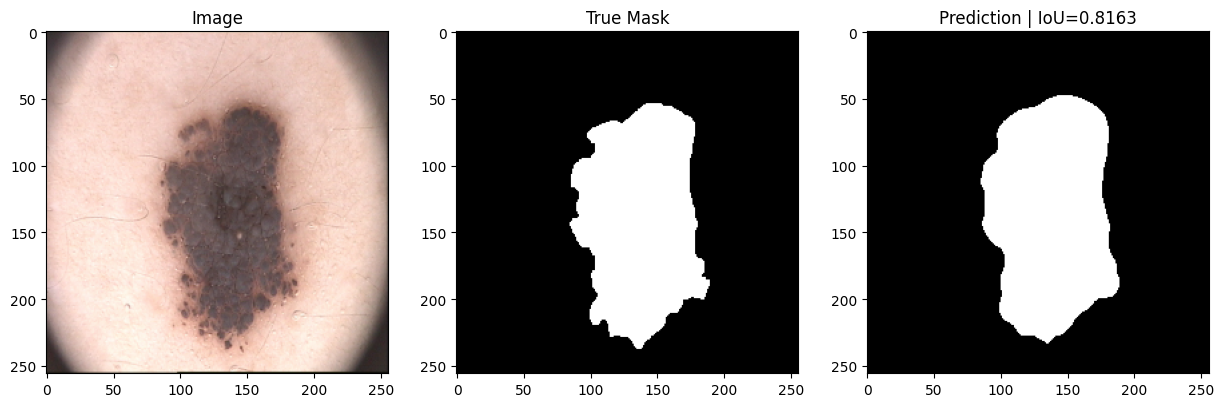

Train Loss: 0.1324
Val Loss:   0.1504
Val IoU:    0.8163


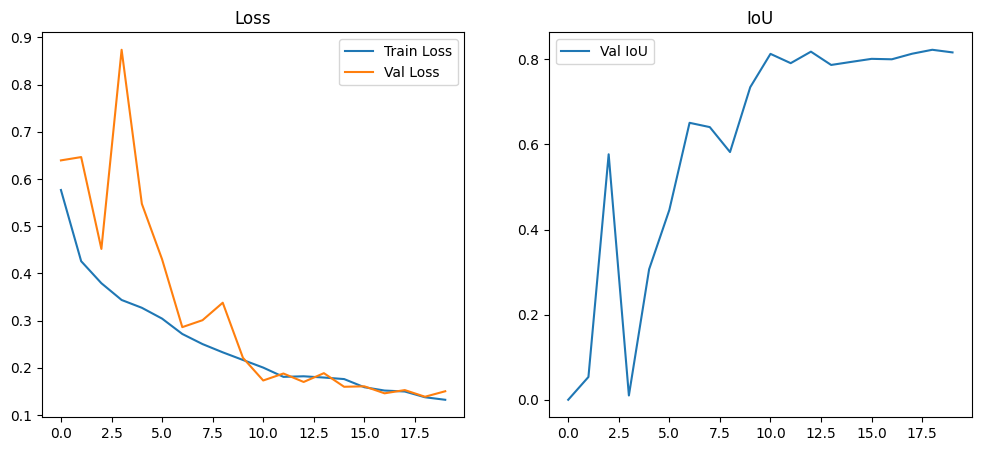

In [ ]:
ckpt_path_unet_dice = "/content/checkpoints/unet_dice"

os.makedirs(ckpt_path_unet_dice, exist_ok=True)

model_unet_dice = UNet(n_class=1).to(device)
optimizer_unet_dice = torch.optim.Adam(model_unet_dice.parameters(), lr=1e-3)
criterion_dice = dice_loss

model_unet_dice, stats_unet_dice = train(
    model_unet_dice,
    optimizer_unet_dice,
    criterion_dice,
    epochs,
    train_dataloader,
    valid_dataloader,
    device,
    ckpt_path_unet_dice,
    plot_loss=True
)

### Focal loss

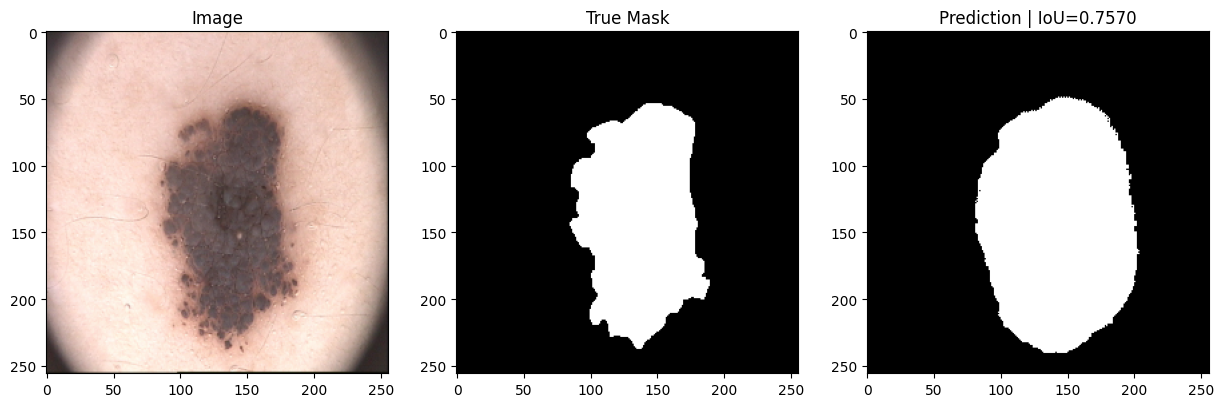

Train Loss: 0.0479
Val Loss:   0.0790
Val IoU:    0.7570


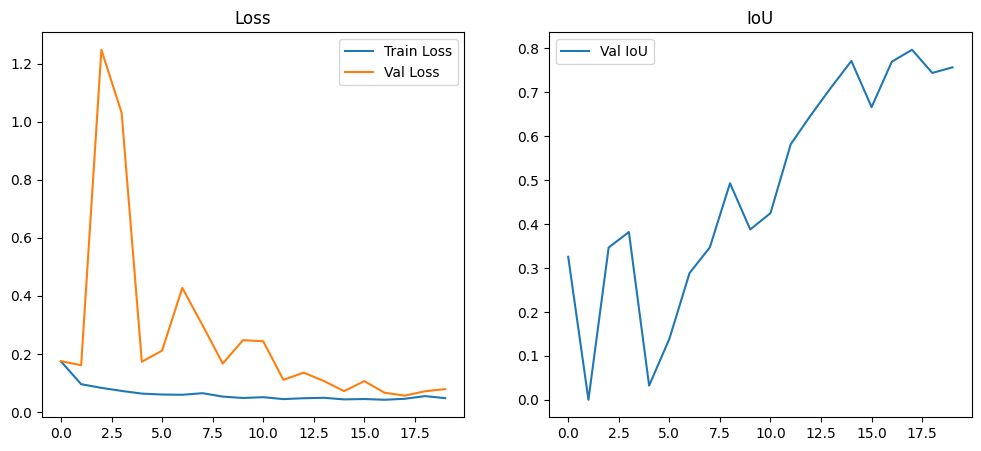

In [ ]:
ckpt_path_unet_focal = "/content/checkpoints/unet_focal"

os.makedirs(ckpt_path_unet_focal, exist_ok=True)

model_unet_focal = UNet(n_class=1).to(device)
optimizer_unet_focal = torch.optim.Adam(model_unet_focal.parameters(), lr=1e-3)
criterion_focal = focal_loss

model_unet_focal, stats_unet_focal = train(
    model_unet_focal,
    optimizer_unet_focal,
    criterion_focal,
    epochs,
    train_dataloader,
    valid_dataloader,
    device,
    ckpt_path_unet_focal,
    plot_loss=True
)

- по метрике лучшие значения дает модель с dice loss (0,8163)
- по лоссам лучшие значения дает модель с focal loss (0,079)
- быстрее обучается модель с dice loss

## Сравнение SegNet и UNet

Сравним визуально SegNet и UNet

In [ ]:
def show_prediction(model, batch, device, title="Model"):
    """
    Визуализация результата сегментации:
    - исходное изображение
    - ground truth mask
    - предсказанная маска
    """

    model.eval()

    with torch.no_grad():

        x, y = batch
        x = x.to(device)

        pred = torch.sigmoid(model(x))[0, 0].cpu()

        img = x[0].permute(1, 2, 0).cpu()
        true_mask = y[0, 0].cpu()

        fig, ax = plt.subplots(1, 3, figsize=(12, 4))

        ax[0].imshow(img)
        ax[0].set_title(f"{title} - Image")
        ax[0].axis("off")

        ax[1].imshow(true_mask, cmap="gray")
        ax[1].set_title("Ground Truth")
        ax[1].axis("off")

        ax[2].imshow(pred > 0.5, cmap="gray")
        ax[2].set_title("Prediction")
        ax[2].axis("off")

        plt.show()

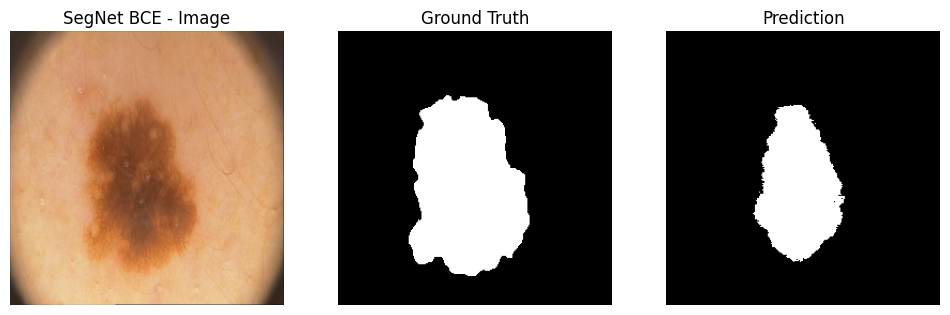

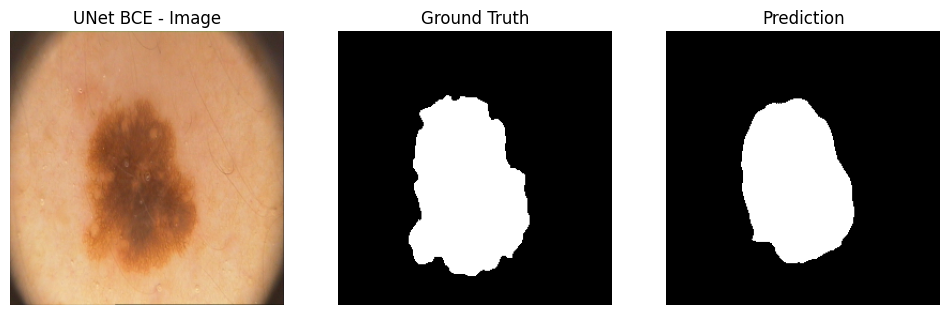

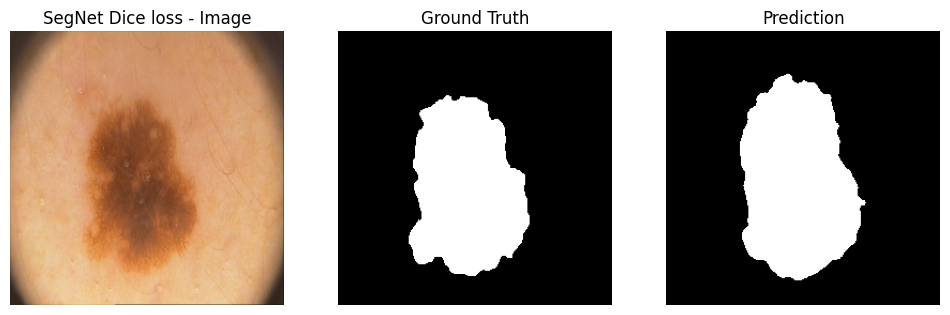

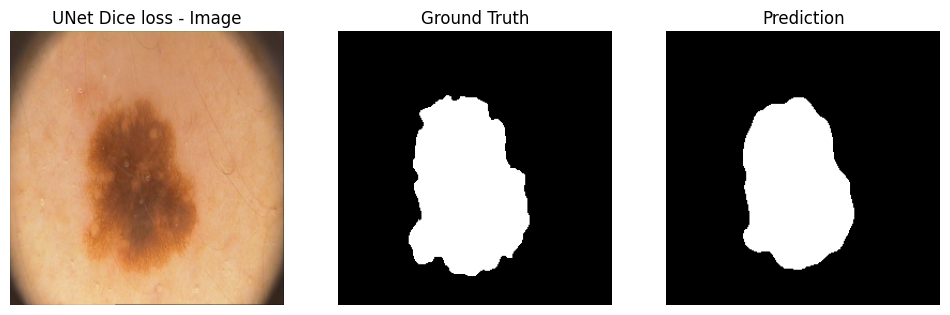

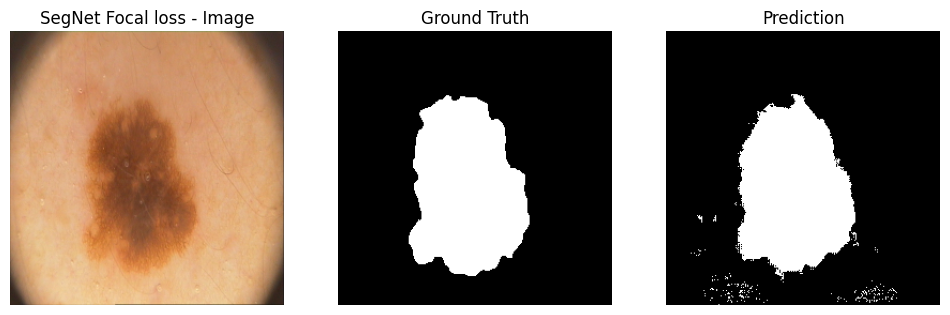

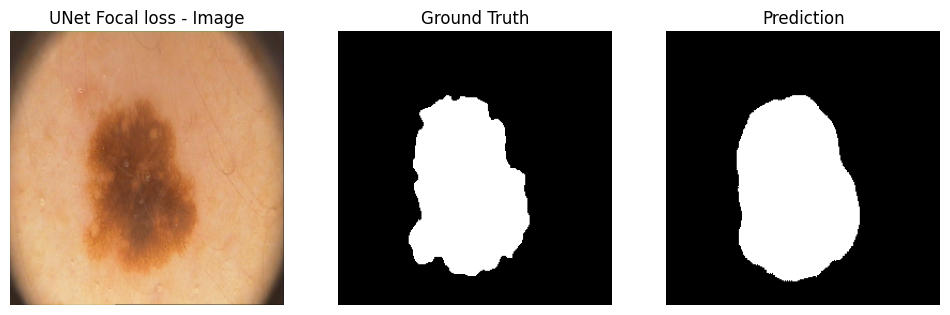

In [ ]:
import random

X, Y = next(iter(valid_dataloader))

idx = random.randint(0, X.size(0) - 1)

sample = (X[idx:idx+1], Y[idx:idx+1])

show_prediction(model_bce, sample, device, title="SegNet BCE")
show_prediction(model_unet_bce, sample, device, title="UNet BCE")
show_prediction(model_dice, sample, device, title="SegNet Dice loss")
show_prediction(model_unet_dice, sample, device, title="UNet Dice loss")
show_prediction(model_focal, sample, device, title="SegNet Focal loss")
show_prediction(model_unet_focal, sample, device, title="UNet Focal loss")

Наилучшее предсказание визуально получается у SegNet с dice loss